## Load Image

In [1]:
from matplotlib import pyplot as plt
import cv2 as cv
import numpy as np

In [2]:
image = cv.imread("zebra.jpg")
img_h, img_w, img_c = image.shape
image.shape

(391, 586, 3)

(np.float64(-0.5), np.float64(585.5), np.float64(390.5), np.float64(-0.5))

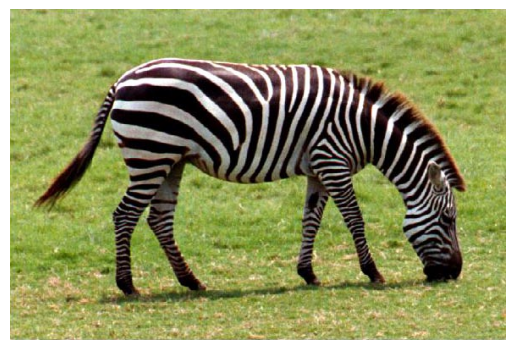

In [3]:
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.axis("off")

In [4]:
image_data = image.reshape((-1, 3))
image_data.shape

(229126, 3)

## Gaussian Mixture Model

In [5]:
from sklearn.mixture import GaussianMixture

In [6]:
gmm= GaussianMixture(n_components=2, covariance_type='full', random_state=0)

In [7]:
gmm.fit(image_data)

,n_components,2
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,0


In [8]:
labels = gmm.predict(image_data)

In [9]:
labels.shape

(229126,)

In [10]:
labels = labels.reshape((img_h, img_w, 1))

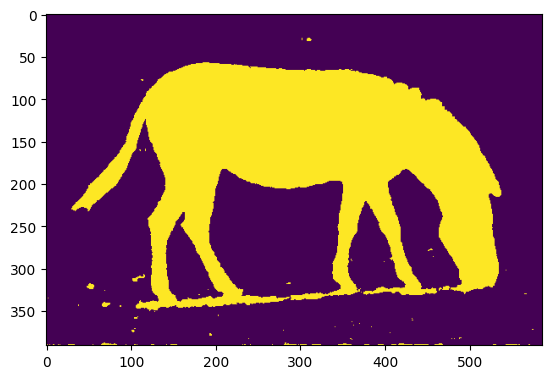

In [11]:
plt.imshow(labels)

## Segment the image

In [12]:
segmented_image = np.zeros_like(image)
segmented_image = np.where(labels==0, 225, image).astype(np.uint8)

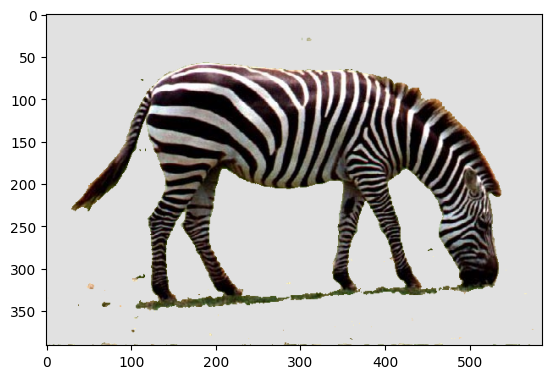

In [13]:
plt.imshow(cv.cvtColor(segmented_image, cv.COLOR_BGR2RGB))

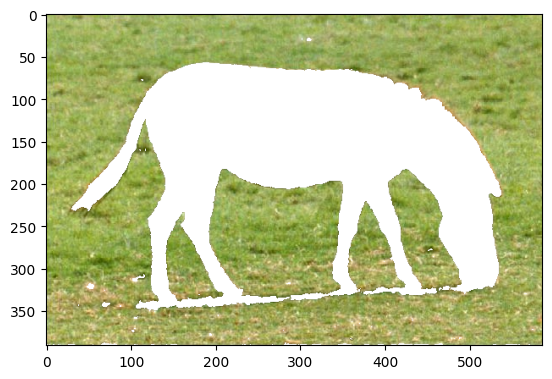

In [14]:
segmented_image = np.where(labels == 1, 255, image).astype(np.uint8)
plt.imshow(cv.cvtColor(segmented_image, cv.COLOR_BGR2RGB))


## Test with another picture

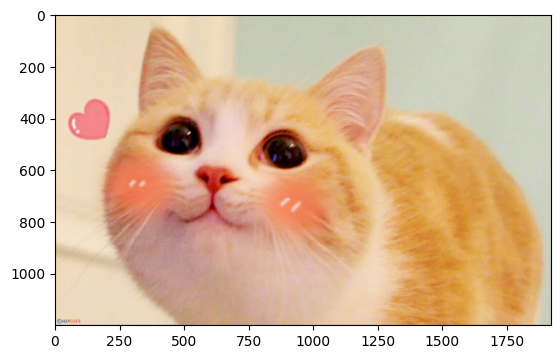

In [15]:
test_image = cv.imread("test/meo.jpg")
test_h, test_w, test_c = test_image.shape
plt.imshow(cv.cvtColor(test_image, cv.COLOR_BGR2RGB))

In [16]:
test_image_data = test_image.reshape((-1, 3))
test_image_data.shape

(2304000, 3)

In [17]:
gmm.fit(test_image_data)

,n_components,2
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,0


In [18]:
labels = gmm.predict(test_image_data)
labels = labels.reshape((test_h, test_w, 1)) 

In [19]:
segmented_test_image = np.zeros_like(test_image)

In [20]:
segmented_test_image = np.where(labels==1, 255, test_image).astype(np.uint8)

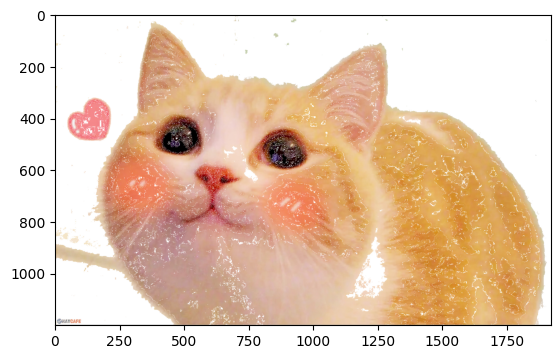

In [21]:
plt.imshow(cv.cvtColor(segmented_test_image, cv.COLOR_BGR2RGB))